In [1]:
#This is the main assignment for ITNPBD2, Spring 2026.
print("The main assignment for ITNPBD2, Spring 2026.")
print("University of Stiring")

The main assignment for ITNPBD2, Spring 2026.
University of Stiring


In [2]:
#Importing basic libraries 
import pandas as pd
import matplotlib.pyplot as plt
import json

In [3]:
#Loaded the datasets provided
products=pd.read_csv("products.csv")
reviews=pd.read_csv("reviews.csv")
users=pd.read_csv("users.csv")

In [4]:
#Show first few rows of each table
#1
products.head()

,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.125


In [5]:
#2
reviews.head()

,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...
4,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...


In [6]:
#3
users.head()

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


In [7]:
#Checked number of rows and columns in dataset provided
print("Products:",products.shape)
print("Reviews:",reviews.shape)
print("Users:",users.shape)

Products: (7982, 6)
Reviews: (39063, 4)
Users: (5000, 3)


In [8]:
#Data Understanding
#Check column names
products.columns

Index(['Uniq_id', 'SKU', 'Name', 'Description', 'Price', 'Av_Score'], dtype='object')

In [9]:
#Check reviews names of users table
reviews.columns

Index(['Uniq_id', 'Username', 'Score', 'Review'], dtype='object')

In [10]:
#Check column names of users table
users.columns

Index(['Username', 'DOB', 'State'], dtype='object')

In [11]:
#Convert column names to lowercase
products.columns=products.columns.str.lower()
reviews.columns=reviews.columns.str.lower()
users.columns=users.columns.str.lower()

In [12]:
products.columns
reviews.columns
users.columns

Index(['username', 'dob', 'state'], dtype='object')

In [13]:
#Checked how many times each score appears
reviews["score"].value_counts()
#below output tells the No. of score given by people

score
1    11687
0    11265
2     7957
3     4007
4     2245
5     1902
Name: count, dtype: int64

In [14]:
#Remove rows where score is 0
#score 0 might be Invalid
reviews_clean=reviews[reviews["score"]>0]

In [15]:
#Checked score distribution after removing 0
reviews_clean["score"].value_counts().sort_index()

score
1    11687
2     7957
3     4007
4     2245
5     1902
Name: count, dtype: int64

In [16]:
#clear comparison before and after 0
print("Before removing 0:")
print(reviews["score"].value_counts().sort_index())

print("\nAfter removing 0:")
print(reviews_clean["score"].value_counts().sort_index())

Before removing 0:
score
0    11265
1    11687
2     7957
3     4007
4     2245
5     1902
Name: count, dtype: int64

After removing 0:
score
1    11687
2     7957
3     4007
4     2245
5     1902
Name: count, dtype: int64


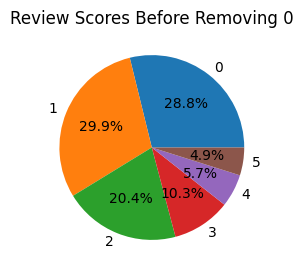

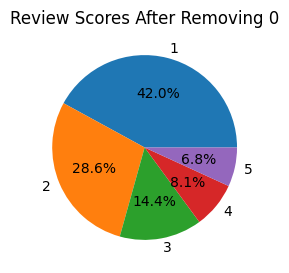

In [17]:
#Understanding score distribution before and after removing 0 by pie chart visualization
#Count scores before removing 0
score_counts_before=reviews["score"].value_counts().sort_index()

#Count scores after removing 0
score_counts_after=reviews_clean["score"].value_counts().sort_index()
#first pie chart(before cleaning)
plt.figure(figsize=(3,3))
plt.pie(score_counts_before, labels=score_counts_before.index, autopct="%1.1f%%")
plt.title("Review Scores Before Removing 0")
plt.show()
#second pie chart (after cleaning)
plt.figure(figsize=(3,3))
plt.pie(score_counts_after, labels=score_counts_after.index, autopct="%1.1f%%")
plt.title("Review Scores After Removing 0")
plt.show()

In [18]:
#Combine review data with product data
#This helps us analyse product performance
#Merge reviews with product details using uniq_id
merged=reviews_clean.merge(products,on="uniq_id")
#Showes first few rows
merged.head()


,uniq_id,username,score,review,sku,name,description,price,av_score
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,b6c0b6bea69c722939585baeac73c13d,nvfn3212,3,This product is very comfortable and the fabri...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
4,b6c0b6bea69c722939585baeac73c13d,aajh3423,2,I did not like the fabric. It is 100% polyeste...,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625


In [19]:
#Group by product name
#Calculate average score and number of reviews
product_summary=merged.groupby("name")["score"].agg(["mean","count"]).reset_index()
#Show first few rows
product_summary.head()
#Group reviews by product
#Calculate average rating (mean)
#Count number of reviews

,name,mean,count
0,1 CT. Certified Diamond Solitaire Ring,2.333333,3
1,1 CT. T.W. Certified Diamond 14K White Gold Br...,5.000000,1
2,1 CT. T.W. Certified Diamond 14K White Gold Pr...,1.000000,1
3,1 CT. T.W. Certified Diamond 14K Yellow Gold B...,1.000000,1
4,1 CT. T.W. Diamond 10K White Gold Flower Ring,5.000000,1


In [20]:
#Keep only products with at least 10 reviews
reliable_products=product_summary[product_summary["count"]>=10]
reliable_products.head()
#Keep only products with enough reviews
#This makes analysis more reliable

,name,mean,count
26,10K Yellow Gold Hollow 24” Rope Chain,2.333333,15
57,A2 by Aerosoles® Light N Sweet Wedge Sandals,2.066667,15
62,A2 by Aerosoles® Stone Plush Wedge Sandals,1.909091,11
64,A2 by Aerosoles® Wipline Thong Sandals,1.875000,16
68,ARDENCY INN Modster Smooth Ride Supercharged E...,1.727273,11


In [21]:
#Here very important:
#mean=average rating of the product
#count=number of reviews for the product or how many people gave rating to the product

In [22]:
#Sort by average rating (low to high)
worst_products=reliable_products.sort_values("mean").head(10)
worst_products

,name,mean,count
3059,Magnum Precision Ultra Lite II Mens Composite-...,1.066667,15
444,Arizona Schoolgirl Bootcut Pants - Juniors Plus,1.181818,11
4693,The Foundry Supply Co.™ Short-Sleeve Quick-Dri...,1.181818,11
74,ASSETS Red Hot Label by Spanx High-Waist Panti...,1.300000,10
2553,Levis® 510™ Skinny Jeans - Boys 8-20,1.307692,13
907,Champion® Rugby Shorts,1.333333,12
303,Arizona Collette Womens Boots,1.357143,14
4177,St. Johns Bay® 3/4 Sleeve V-Neck Peasant Shirt,1.357143,14
1987,I. Miller Fair Metallic Strappy Wedge Sandals,1.357143,14
2407,KitchenAid® Artisan® 5-qt. Stand Mixer KSM150PS,1.363636,11


In [23]:
#Sort by average rating (high to low)
best_products=reliable_products.sort_values("mean",ascending=False).head(10)
best_products

,name,mean,count
1688,GE® ENERGY STAR® 4.3 DOE Cu. ft. High Efficien...,3.500000,14
4343,Stafford® 4-pk. Heavyweight Crewneck T-Shirts–...,3.333333,12
5100,Xersion™ Compression Slider Shorts,3.272727,11
153,Alfred Dunner® Twill Pull-On Pants,3.181818,11
584,Bali® Live It Up® Underwire Bra - 3353,3.052632,19
5024,Worthington® Seamless Cami - Petite,3.000000,11
2566,Levis® 517™ Bootcut Jeans,3.000000,13
2468,Lamont Home® Woven Jacquard Bedspread & Access...,3.000000,13
792,Call It Spring™ Chaella Ballet Flats,2.928571,14
1931,Home Expressions™ Microfiber Twin XL Sheet Set,2.916667,12


In [24]:
# We only consider products with at least 10 reviews
# because products with very few reviews are not reliable

In [25]:
#Recreated summary including price for price analysis
#Group by product name and price
#Calculate average rating and number of reviews
product_summary=(
    merged.groupby(["name","price"])["score"]
    .agg(["mean","count"])
    .reset_index()
)

In [26]:
reliable_products=product_summary[product_summary["count"]>=10]

In [27]:
#Check correlation between price and rating
reliable_products["mean"].corr(reliable_products["price"])
#Check if there is any relationship between price and average rating

0.08127577158321593

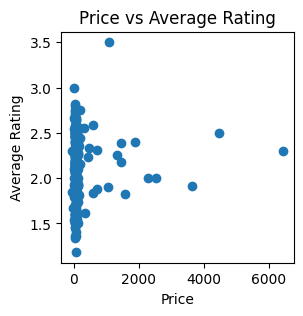

In [28]:
#understanding by scatter plot
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
plt.scatter(reliable_products["price"],reliable_products["mean"])
plt.xlabel("Price")
plt.ylabel("Average Rating")
plt.title("Price vs Average Rating")
plt.show()


In [29]:
#Checked if expensive products get better ratings
#If correlation is close to 0, price does not affect rating much


In [30]:
#Now, Finding Risk Products & Opportunity Products

In [31]:
#Check average price and rating
reliable_products[["mean", "price"]].describe()

,mean,price
count,272.000000,272.000000
mean,2.096234,179.291912
std,0.337014,593.523700
min,1.181818,-58.010000
25%,1.857143,42.300000
50%,2.090909,57.520000
75%,2.333333,84.000000
max,3.500000,6440.300000


In [32]:
#Risk products:
#High price but low rating
risk_products = reliable_products[
    (reliable_products["price"] > reliable_products["price"].mean()) &
    (reliable_products["mean"] < reliable_products["mean"].mean())
]
risk_products.sort_values("mean").head(10)

,name,price,mean,count
3442,Stafford® Executive Super 100 Wool Suit Jacket...,332.37,1.619048,21
1329,GE® 4.8 DOE Cu. ft. Capacity RightHeight™ Desi...,1570.00,1.826087,23
1353,GE® ENERGY STAR® Dishwasher with Front Controls,603.10,1.833333,12
1356,GE® ENERGY STAR® Dishwasher with Hidden Controls,723.97,1.875000,16
1177,Dyson® Cinetic™ Big Ball Animal Upright Vacuum...,1039.42,1.900000,10
3122,Samsung ENERGY STAR® 29 cu. ft. 36” Wide Side-...,3624.67,1.916667,12
1302,GE Profile™ 27-in. Single Wall Oven with Advan...,2295.18,2.000000,11
1878,LG ENERGY STAR® 28 cu. ft. Ultra Large Capacit...,2536.90,2.000000,11


In [33]:
#Above shows:
#Products that are expensive but poorly rated
#These may damage brand image or reduce sales

In [34]:
#Opportunity products:
#Low price but high rating
opportunity_products=reliable_products[
    (reliable_products["price"]<reliable_products["price"].mean()) &
    (reliable_products["mean"]>reliable_products["mean"].mean())
]
opportunity_products.sort_values("mean", ascending=False).head(10)

,name,price,mean,count
4010,Worthington® Seamless Cami - Petite,18.92,3.000000,11
4301,a.n.a® Long-Sleeve Colorblock Layered-Look T-S...,43.09,2.823529,17
4174,Xersion™ Quick-Dri Short-Sleeve Polo Shirt,42.30,2.800000,10
592,Brooklyn Xpress Fleece Jogger Pants,53.18,2.750000,16
4033,Worthington® Slim Ankle Pants - Tall,53.18,2.727273,11
2763,Nike® Victory Compression Bra,35.47,2.692308,13
3454,Stafford® Fleece Pajama Pants,42.30,2.666667,15
95,Alfred Dunner® Feels Like Spring Capris,58.01,2.666667,15
3360,St. Johns Bay® Short-Sleeve V-Neck T-Shirt,16.92,2.666667,12
765,Champion® Vapor Short-Sleeve Tee - Big & Tall,40.70,2.640000,25


In [35]:
#Above shows:
#Products that are affordable and highly rated
#These can be promoted more for better sales

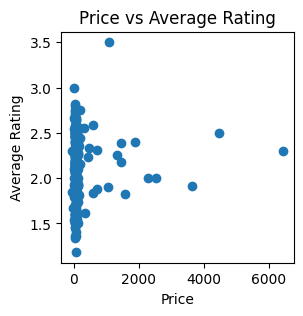

In [36]:
import matplotlib.pyplot as plt

#Create scatter plot
plt.figure(figsize=(3,3))
plt.scatter(reliable_products["price"],reliable_products["mean"])

plt.xlabel("Price")
plt.ylabel("Average Rating")
plt.title("Price vs Average Rating")
plt.show()

In [37]:
#This graph shows how price and rating are related
#Each dot represents one product
#Checked if expensive products have better ratings

In [38]:
#Now,
#Overall average rating of reliable products
overall_avg = reliable_products["mean"].mean()
overall_avg

2.0962343967123798

In [39]:
#Check overall average price
overall_price = reliable_products["price"].mean()
overall_price

179.2919117647059

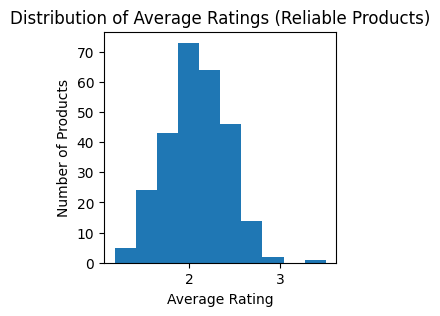

In [40]:
#Final view: distribution of average product ratings

plt.figure(figsize=(3,3))
plt.hist(reliable_products["mean"],bins=10)
plt.xlabel("Average Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Average Ratings (Reliable Products)")
plt.show()

In [41]:
#This shows how product ratings are distributed
#checked if most products have low or high ratings

In [42]:
#Final Summary:
#Zero ratings were removed to clean the data.
#Products were grouped to calculate average rating.
#Only products with at least 10 reviews were considered reliable.
#Overall average rating is around 2.09 (low satisfaction).
#Correlation between price and rating is very weak(0.08).
#Price does not strongly influence customer satisfaction.
#Some high-priced products have low ratings (risk).
#Some low-priced products have high ratings (opportunity).

In [43]:
print("\nFINAL BUSINESS INSIGHT")
print("="*50)

print(f"Overall average rating (reliable products):{reliable_products['mean'].mean():.2f}")
print(f"Overall average price: £{reliable_products['price'].mean():.2f}")

print("\nKey Findings:")
print("-Customer satisfaction is generally low.")
print("-Price does not show strong relationship with rating.")
print("-Improvement focus should be on product quality and customer experience.")


FINAL BUSINESS INSIGHT
Overall average rating (reliable products):2.10
Overall average price: £179.29

Key Findings:
-Customer satisfaction is generally low.
-Price does not show strong relationship with rating.
-Improvement focus should be on product quality and customer experience.
